In [4]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, os
sns.set_theme(style="whitegrid")
P = r"C:\Users\harsh\Downloads\churn-project (1)\churn-project"
df = pd.read_csv(os.path.join(P, "data", "churn_clean.csv"))
FIG = os.path.join(P, "reports", "figures")
os.makedirs(FIG, exist_ok=True)
df.shape

(10000, 11)

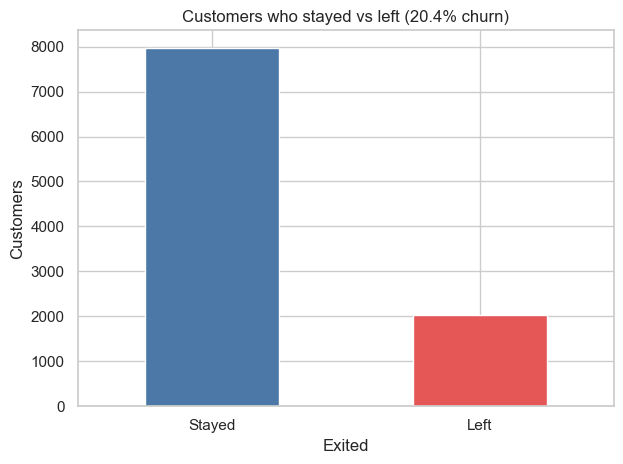

In [5]:
ax = df["Exited"].value_counts().sort_index().plot(kind="bar", color=["#4C78A8", "#E45756"])
ax.set_xticklabels(["Stayed", "Left"], rotation=0)
ax.set_title("Customers who stayed vs left (20.4% churn)")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "01_churn_rate.png"), dpi=150)
plt.show()

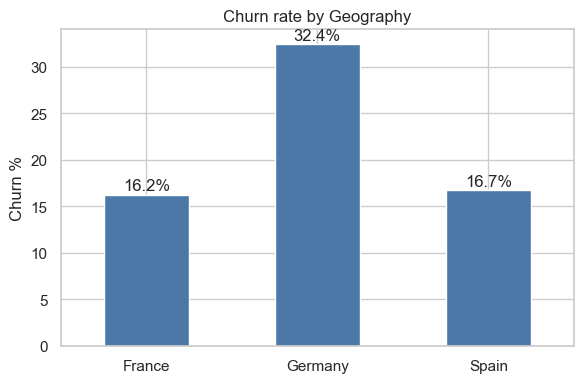

{'France': 16.2, 'Germany': 32.4, 'Spain': 16.7}


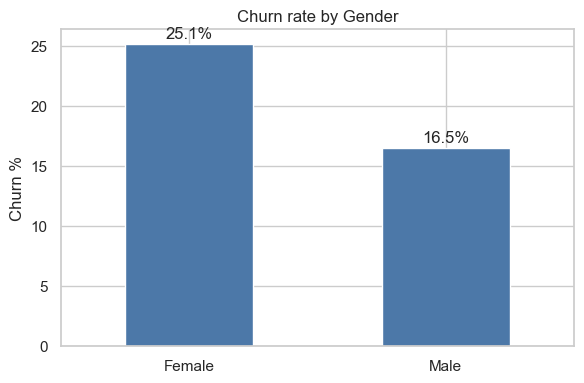

{'Female': 25.1, 'Male': 16.5}


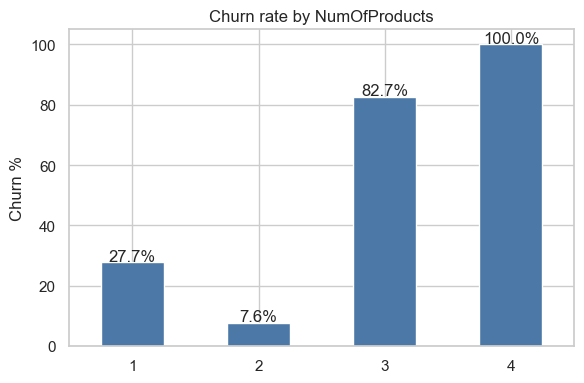

{1: 27.7, 2: 7.6, 3: 82.7, 4: 100.0}


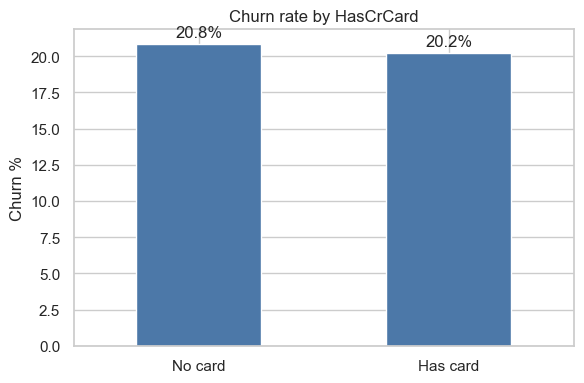

{0: 20.8, 1: 20.2}


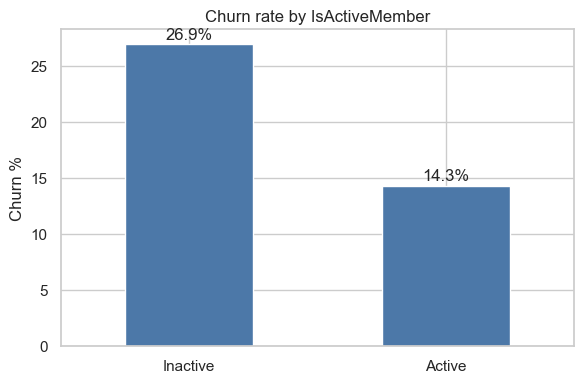

{0: 26.9, 1: 14.3}


In [6]:
def churn_bar(col, labels=None, n=0):
    rate = df.groupby(col)["Exited"].mean().mul(100).round(1)
    ax = rate.plot(kind="bar", color="#4C78A8", figsize=(6, 4))
    for i, v in enumerate(rate):
        ax.text(i, v + 0.5, f"{v}%", ha="center")
    if labels: ax.set_xticklabels(labels)
    ax.set_xticks(range(len(rate))); ax.tick_params(axis="x", rotation=0)
    ax.set_title(f"Churn rate by {col}"); ax.set_ylabel("Churn %"); ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, f"{n:02d}_churn_by_{col}.png"), dpi=150)
    plt.show()
    print(rate.to_dict())

churn_bar("Geography", n=2)
churn_bar("Gender", n=3)
churn_bar("NumOfProducts", n=4)
churn_bar("HasCrCard", ["No card", "Has card"], n=5)
churn_bar("IsActiveMember", ["Inactive", "Active"], n=6)

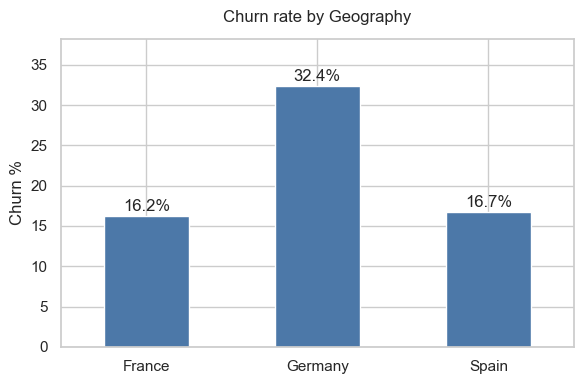

{'France': 16.2, 'Germany': 32.4, 'Spain': 16.7}


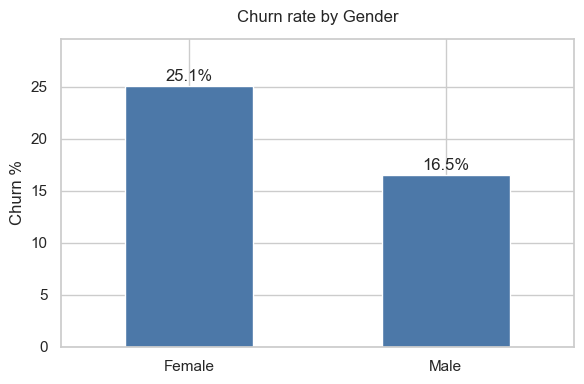

{'Female': 25.1, 'Male': 16.5}


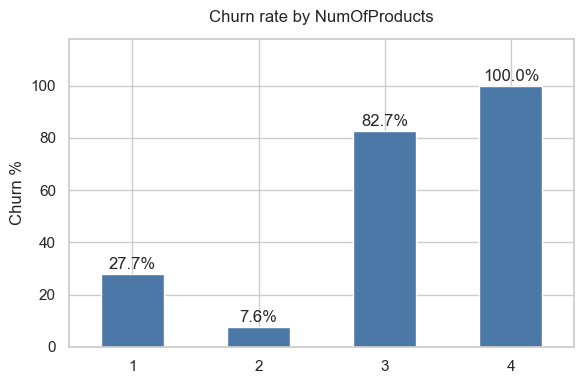

{1: 27.7, 2: 7.6, 3: 82.7, 4: 100.0}


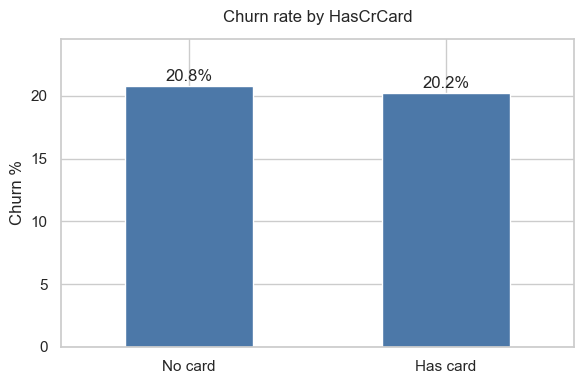

{0: 20.8, 1: 20.2}


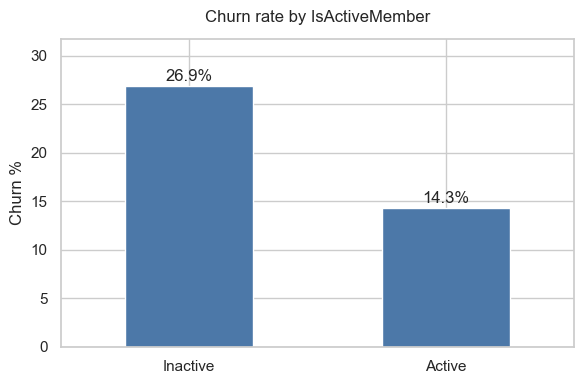

{0: 26.9, 1: 14.3}


In [7]:
def churn_bar(col, labels=None, n=0):
    rate = df.groupby(col, observed=True)["Exited"].mean().mul(100).round(1)
    ax = rate.plot(kind="bar", color="#4C78A8", figsize=(6, 4))
    ax.set_ylim(0, rate.max() * 1.18)
    for i, v in enumerate(rate):
        ax.text(i, v + rate.max() * 0.02, f"{v}%", ha="center")
    ax.set_xticks(range(len(rate)))
    if labels: ax.set_xticklabels(labels)
    ax.tick_params(axis="x", rotation=0)
    ax.set_title(f"Churn rate by {col}", pad=12); ax.set_ylabel("Churn %"); ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, f"{n:02d}_churn_by_{col}.png"), dpi=150)
    plt.show()
    print(rate.to_dict())

churn_bar("Geography", n=2)
churn_bar("Gender", n=3)
churn_bar("NumOfProducts", n=4)
churn_bar("HasCrCard", ["No card", "Has card"], n=5)
churn_bar("IsActiveMember", ["Inactive", "Active"], n=6)

In [8]:
df["NumOfProducts"].value_counts().sort_index()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

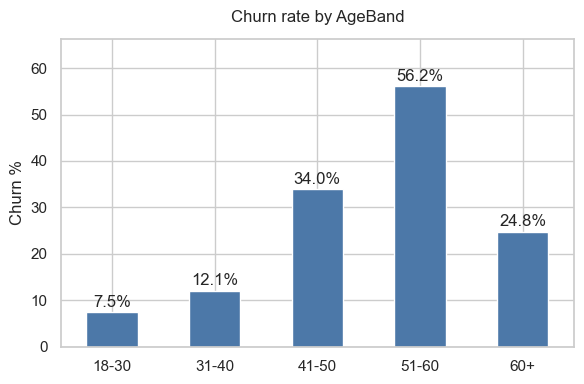

{'18-30': 7.5, '31-40': 12.1, '41-50': 34.0, '51-60': 56.2, '60+': 24.8}


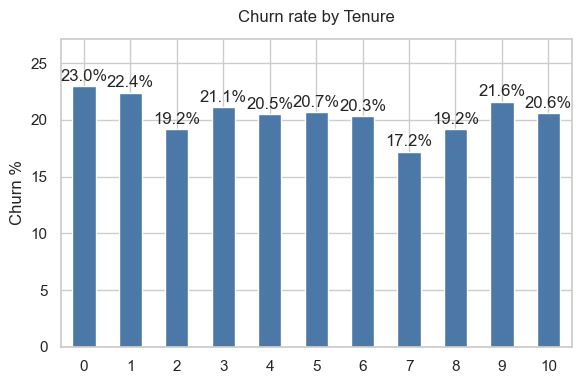

{0: 23.0, 1: 22.4, 2: 19.2, 3: 21.1, 4: 20.5, 5: 20.7, 6: 20.3, 7: 17.2, 8: 19.2, 9: 21.6, 10: 20.6}


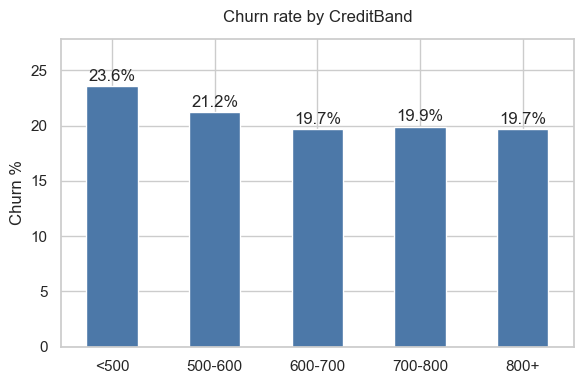

{'<500': 23.6, '500-600': 21.2, '600-700': 19.7, '700-800': 19.9, '800+': 19.7}


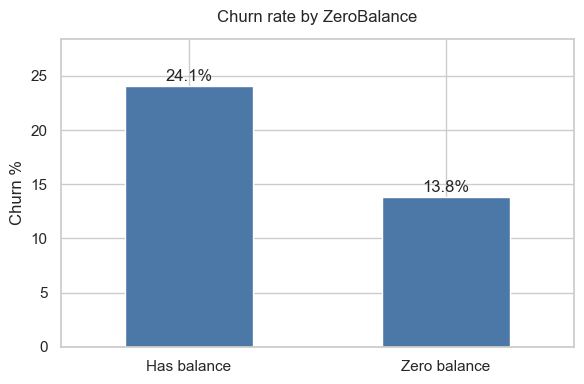

{'Has balance': 24.1, 'Zero balance': 13.8}


In [9]:
df["AgeBand"] = pd.cut(df["Age"], [17, 30, 40, 50, 60, 100], labels=["18-30", "31-40", "41-50", "51-60", "60+"])
df["CreditBand"] = pd.cut(df["CreditScore"], [0, 500, 600, 700, 800, 900], labels=["<500", "500-600", "600-700", "700-800", "800+"])
df["ZeroBalance"] = (df["Balance"] == 0).map({True: "Zero balance", False: "Has balance"})

churn_bar("AgeBand", n=7)
churn_bar("Tenure", n=8)
churn_bar("CreditBand", n=9)
churn_bar("ZeroBalance", n=10)

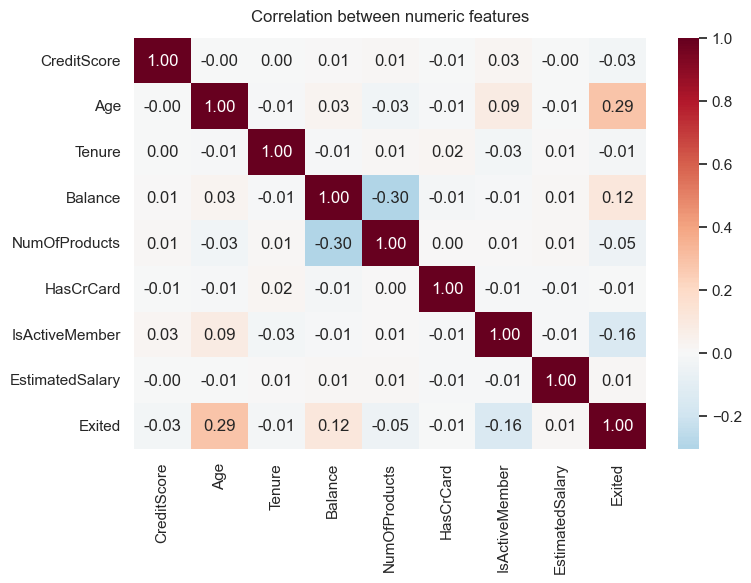

In [10]:
num = df[["CreditScore","Age","Tenure","Balance","NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary","Exited"]]
plt.figure(figsize=(8, 6))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation between numeric features", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG, "11_correlation_heatmap.png"), dpi=150)
plt.show()

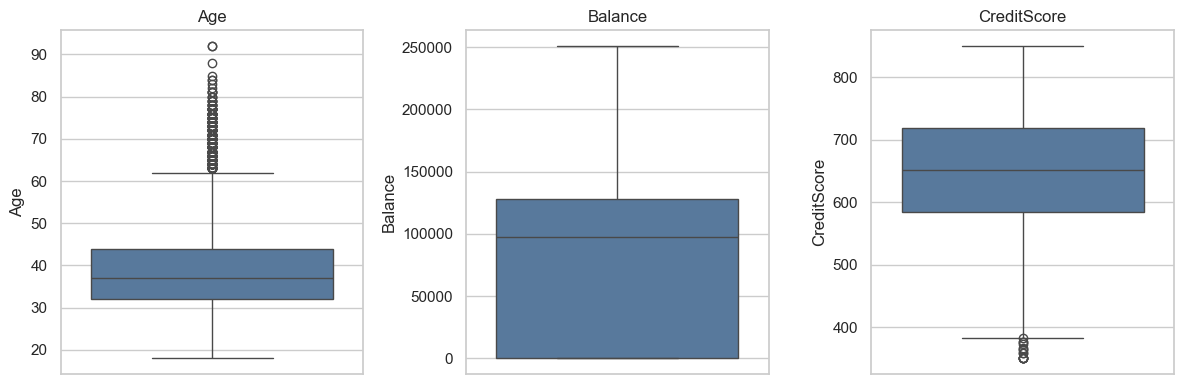

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["Age", "Balance", "CreditScore"]):
    sns.boxplot(y=df[col], ax=ax, color="#4C78A8")
    ax.set_title(col)
plt.tight_layout()
plt.savefig(os.path.join(FIG, "12_outliers.png"), dpi=150)
plt.show()